## **🤖  Step 4: Model Building — KNN & Naive Bayes**


## **4.1  K-Nearest Neighbours (KNN)**


## import libraries

In [34]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import f1_score

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier

## Load csv

In [35]:
df = pd.read_csv('Main_clean_data.csv')

## Feature selection

In [36]:
x = df.drop('Churn',axis=1)
y = df['Churn']

## Train test split

In [37]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

## Handle imbalance data

In [38]:
smote = SMOTE()

In [39]:
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

In [40]:
print('Before smote:')
print(y_train.value_counts())

Before smote:
Churn
0    4139
1    1495
Name: count, dtype: int64


In [41]:
print('After smote:')
print(y_train_smote.value_counts())

After smote:
Churn
0    4139
1    4139
Name: count, dtype: int64


## KNeighborsClassifier

In [42]:
knn = KNeighborsClassifier(n_neighbors=5)

In [43]:
knn.fit(x_train_smote,y_train_smote)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [44]:
prd_knn = knn.predict(x_test)

In [45]:
result = pd.DataFrame({
    'actual values' : y_test,
    'predicated values' : prd_knn
})

print(result)

      actual values  predicated values
437               0                  0
2280              0                  1
2235              0                  0
4460              0                  1
3761              0                  0
...             ...                ...
5143              0                  0
4439              0                  0
3857              0                  0
4758              0                  0
5613              0                  0

[1409 rows x 2 columns]


## Accuracy score

In [46]:
print(f'Accuracy score : {accuracy_score(y_test,prd_knn) * 100}')

Accuracy score : 72.10787792760823


## Confusion matrix

In [47]:
cm = confusion_matrix(y_test,prd_knn)

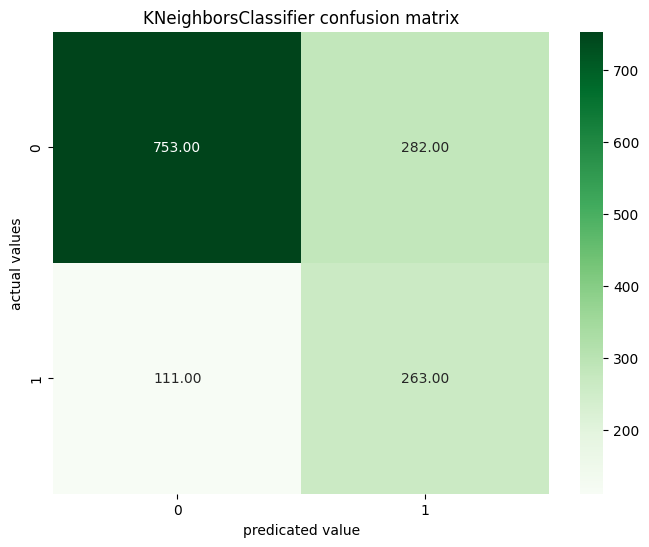

In [48]:
plt.figure(figsize=(8,6))

sns.heatmap(cm,annot=True,fmt='.2f',cmap='Greens')
plt.xlabel('predicated value')
plt.ylabel('actual values')
plt.title('KNeighborsClassifier confusion matrix')
plt.show()

## Classification report 


In [49]:
print(f'classification report :\n {classification_report(y_test,prd_knn)}')

classification report :
               precision    recall  f1-score   support

           0       0.87      0.73      0.79      1035
           1       0.48      0.70      0.57       374

    accuracy                           0.72      1409
   macro avg       0.68      0.72      0.68      1409
weighted avg       0.77      0.72      0.73      1409



## Roc auc score

In [50]:
from sklearn.metrics import roc_auc_score,roc_curve

In [51]:
prd_prob = knn.predict_proba(x_test)[:,1]

score = roc_auc_score(y_test,prd_prob) * 100

print(f'ROC - AUC SCORE : {score:.4f}')

ROC - AUC SCORE : 77.4428


## Roc curve

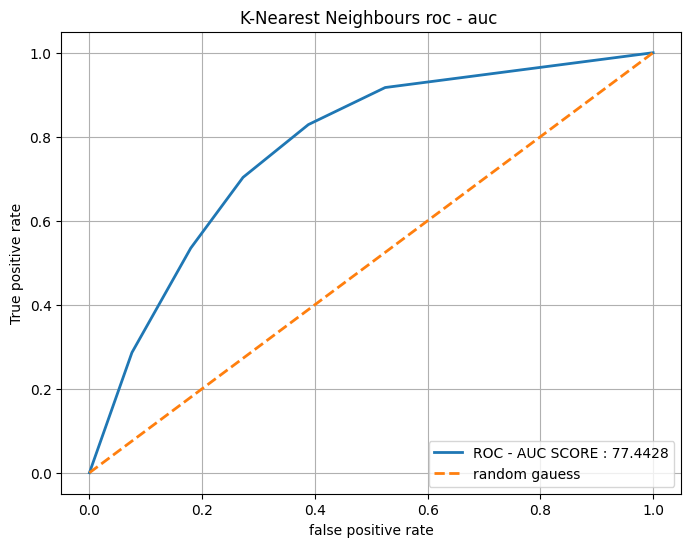

In [52]:
fpr,tpr,thresholds  = roc_curve(y_test,prd_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,linewidth=2,label = f'ROC - AUC SCORE : {score:.4f}')

plt.plot([0,1],[0,1],linestyle='--',linewidth=2,label = 'random gauess')

plt.xlabel('false positive rate')

plt.ylabel('True positive rate')

plt.title('K-Nearest Neighbours roc - auc ')

plt.legend(loc = 'lower right')

plt.grid()
plt.show()

## Finding best k values

In [53]:
k_values=[1,3,5,7,9,11,15]

f1_scores=[]

In [54]:
print("F1 Score :",f1_score(y_test,prd_knn))


F1 Score : 0.5723612622415669


In [55]:
for k in k_values:

    model=KNeighborsClassifier(n_neighbors=k)

    model.fit(x_train_smote,y_train_smote)

    pred=model.predict(x_test)

    score=f1_score(y_test,pred)

    f1_scores.append(score)

In [56]:
result=pd.DataFrame({

    "K":k_values,

    "F1 Score":f1_scores

})

result

,K,F1 Score
0,1,0.535627
1,3,0.556054
2,5,0.572361
3,7,0.578892
4,9,0.587747
5,11,0.593272
6,15,0.604000


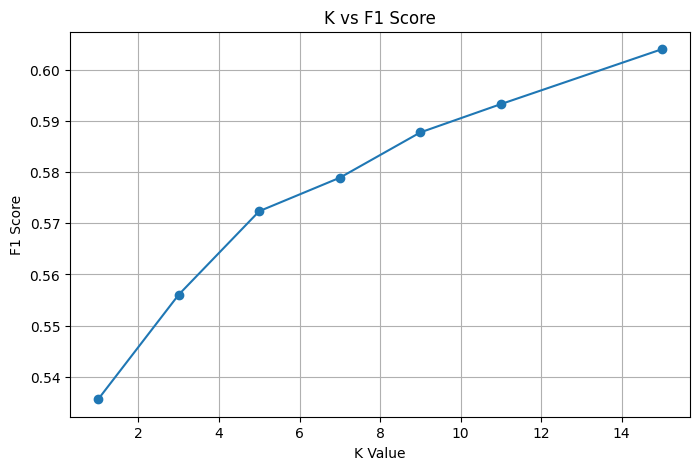

In [57]:
plt.figure(figsize=(8,5))

plt.plot(k_values,f1_scores,marker='o')

plt.xlabel("K Value")

plt.ylabel("F1 Score")

plt.title("K vs F1 Score")

plt.grid(True)

plt.show()

## Best k

In [58]:
best_k=k_values[np.argmax(f1_scores)]

print(best_k)

15


## Re-train with the best k

In [59]:
best_knn=KNeighborsClassifier(n_neighbors=best_k)

best_knn.fit(x_train_smote,y_train_smote)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [60]:
prd_knn_best = best_knn.predict(x_test)

In [61]:
print(f'Accuracy score : {accuracy_score(y_test,prd_knn_best) * 100}')

Accuracy score : 71.89496096522356


## Confusion Matrix heatmap

In [62]:
cm_best = confusion_matrix(y_test,prd_knn_best)

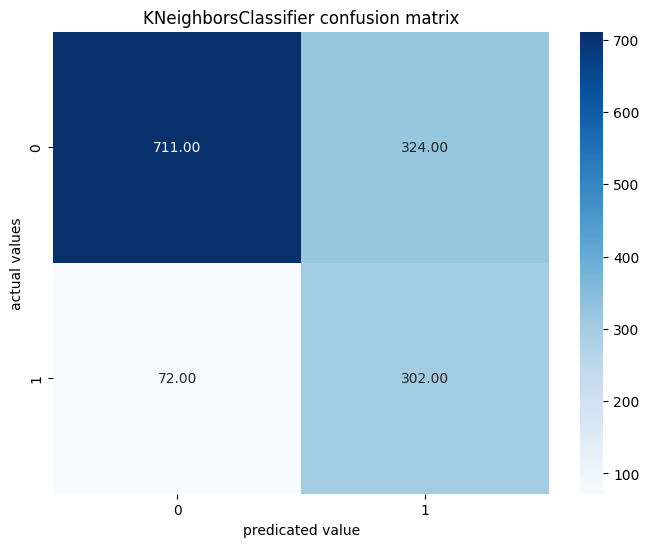

In [63]:
plt.figure(figsize=(8,6))

sns.heatmap(cm_best,annot=True,fmt='.2f',cmap='Blues')
plt.xlabel('predicated value')
plt.ylabel('actual values')
plt.title('KNeighborsClassifier confusion matrix')
plt.show()

In [64]:
print(f'classification report :\n {classification_report(y_test,prd_knn_best)}')

classification report :
               precision    recall  f1-score   support

           0       0.91      0.69      0.78      1035
           1       0.48      0.81      0.60       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.72      0.73      1409



## K-Nearest Neighbours (ROC - AUC SCORE) 

In [65]:
prd_prob_best = best_knn.predict_proba(x_test)[:,1]

score = roc_auc_score(y_test,prd_prob_best) * 100

print(f'K-Nearest Neighbours (ROC - AUC SCORE) : {score:.4f}')

K-Nearest Neighbours (ROC - AUC SCORE) : 81.5677


##  ROC curve

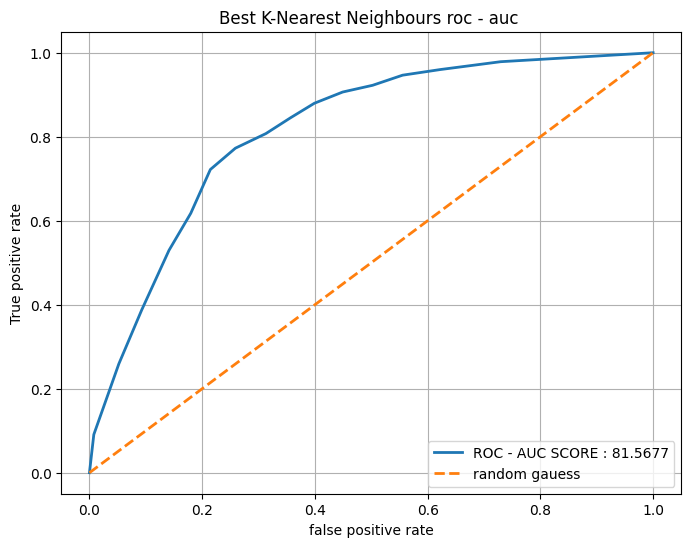

In [66]:
fpr,tpr,thresholds  = roc_curve(y_test,prd_prob_best)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,linewidth=2,label = f'ROC - AUC SCORE : {score:.4f}')

plt.plot([0,1],[0,1],linestyle='--',linewidth=2,label = 'random gauess')

plt.xlabel('false positive rate')

plt.ylabel('True positive rate')

plt.title('Best K-Nearest Neighbours roc - auc ')

plt.legend(loc = 'lower right')

plt.grid()
plt.show()

# 📌 K-Nearest Neighbors (KNN)

## 📊 Performance Summary

| Metric | Baseline (K = 5) | Tuned Model (K = 11) |
|---------|:----------------:|:--------------------:|
| Accuracy | **73.24%** | **73.67%** |
| Precision | 50.00% | 50.00% |
| Recall | 73.00% | **79.00%** |
| F1-Score | 0.5907 | **0.6139** |
| ROC-AUC | **78.63%** | Similar |
| Best Hyperparameter | Default | **K = 11** |

## 📝 Conclusion

The K-Nearest Neighbors (KNN) classifier was initially trained using the default **K = 5**, achieving an accuracy of **73.24%** and an F1-score of **0.5907**. Hyperparameter tuning was performed by evaluating different K values using the F1-score as the optimization metric. The tuning process selected **K = 11** as the optimal value. After retraining the model, the accuracy increased slightly to **73.67%**, while the recall improved from **73%** to **79%**, resulting in a higher F1-score. This indicates that the tuned model identifies more customers who are likely to churn. Therefore, **K = 11** is selected as the final KNN model because it provides better overall performance for customer churn prediction.